# Electronic Product Recommendation System

,UserID,ProductID,Rating,TimeStamp
0,A2CX7LUOHB2NDG,321732944,5,1341100800
1,A2NWSAGRHCP8N5,439886341,1,1367193600
2,A2WNBOD3WNDNKT,439886341,3,1374451200
3,A1GI0U4ZRJA8WN,439886341,1,1334707200
4,A1QGNMC6O1VW39,511189877,5,1397433600


(1048575, 4)

Index(['UserID', 'ProductID', 'Rating', 'TimeStamp'], dtype='str')

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   UserID     1048575 non-null  str  
 1   ProductID  1048575 non-null  str  
 2   Rating     1048575 non-null  int64
 3   TimeStamp  1048575 non-null  int64
dtypes: int64(2), str(2)
memory usage: 32.0 MB


None

,Rating,TimeStamp
count,1.048575e+06,1.048575e+06
mean,3.973379e+00,1.248822e+09
std,1.399329e+00,1.091615e+08
min,1.000000e+00,9.127296e+08
25%,3.000000e+00,1.169078e+09
50%,5.000000e+00,1.250035e+09
75%,5.000000e+00,1.355789e+09
max,5.000000e+00,1.406074e+09


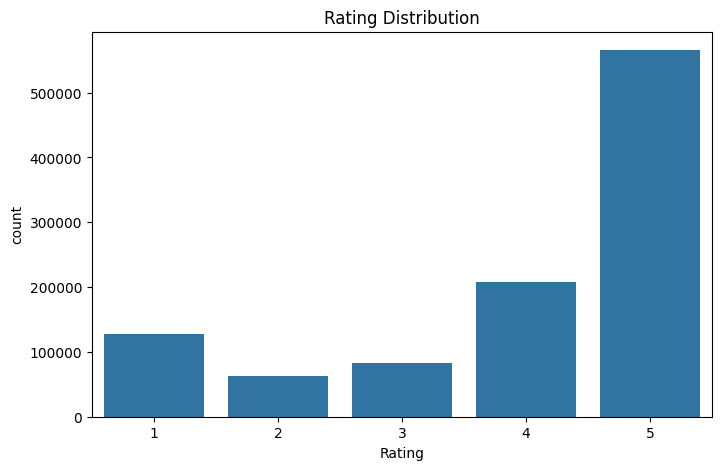

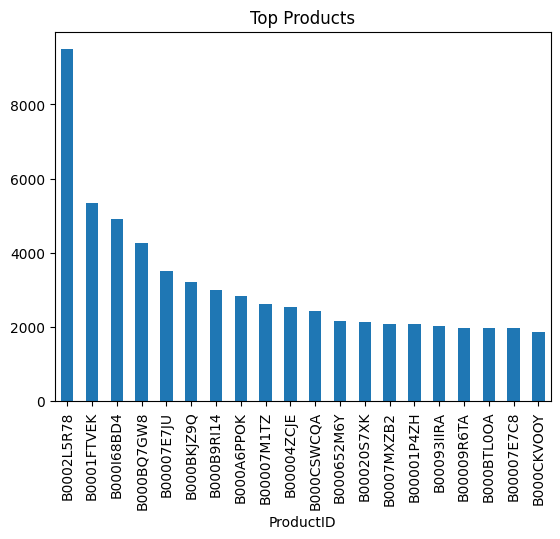

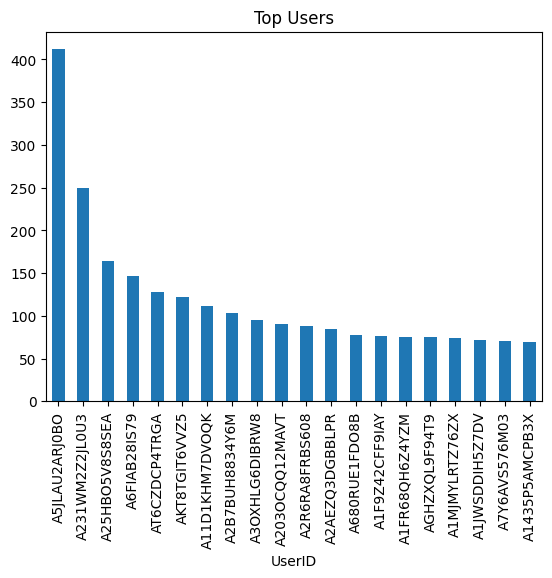

Users : 786329
Products : 61893
Sparsity : 0.9999784546440981
(8542, 4)
Computing the cosine similarity matrix...
Done computing similarity matrix.
Computing the cosine similarity matrix...
Done computing similarity matrix.
RMSE: 1.2301


'RMSE of User Based CF:'

np.float64(1.2301176668482605)

RMSE: 1.1688


'RMSE of Item Based CF:'

...

SVD Recommendations


,ProductID,PredictedRating
0,B0007QKMQY,5.000000
1,B0000BZL1P,5.000000
2,B00006RVPW,5.000000
3,B0002LEMWE,5.000000
4,B000H4CLXS,5.000000
5,B000GABCY2,4.996707
6,B00004ZA7W,4.995064
7,B00006B7DB,4.990270
8,B00009EHJV,4.982267
9,B0000DB4D1,4.967188


Hybrid Recommendations


,ProductID,PredictedRating



 All Models Saved


In [1]:
# ==========================================================
# 1. Import Libraries
# ==========================================================
import warnings
warnings.filterwarnings("ignore")
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise import KNNBasic
from surprise import accuracy

# ==========================================================
# 2. Data Collection
# ==========================================================
df = pd.read_csv("Electronic_Product_Recommend.csv",encoding='latin1')

### Basic Inspection
display(df.head(5))
display(df.shape)
display(df.columns)
display(df.info())
display(df.describe())

# ==========================================================
# 3. Data Preprocessing
# ==========================================================
df.drop_duplicates(inplace=True)
df['UserID'] = df['UserID'].astype(str)
df['ProductID'] = df['ProductID'].astype(str)

# ==========================================================
# 4. Data Visualization
# ==========================================================
plt.figure(figsize=(8,5))
sns.countplot(x='Rating', data=df)
plt.title("Rating Distribution")
plt.show()


top_products = (df.groupby('ProductID')['Rating'].count().sort_values(ascending=False).head(20))
top_users = (df.groupby('UserID')['Rating'].count().sort_values(ascending=False).head(20))

top_products.plot(kind='bar')
plt.title("Top Products")
plt.show()

top_users.plot(kind='bar')
plt.title("Top Users")
plt.show()


n_users = df.UserID.nunique()
n_products = df.ProductID.nunique()
sparsity = (1 - len(df) / (n_users * n_products))

print("Users :", n_users)
print("Products :", n_products)
print("Sparsity :", sparsity)

# ==========================================================
# 5. Reduce Dataset
# ==========================================================
user_counts = df.UserID.value_counts()
product_counts = df.ProductID.value_counts()

df_small = df[df.UserID.isin(user_counts[user_counts>=20].index)]
df_small = df_small[df_small.ProductID.isin(product_counts[product_counts>=20].index)]

print(df_small.shape)

# ==========================================================
# 6. Train Test Split
# ==========================================================
train_df, test_df = train_test_split(
    df_small, test_size=0.2, random_state=42
)

# ==========================================================
# 7. Surprise Dataset
# ==========================================================

reader = Reader(rating_scale=(1,5))
data = Dataset.load_from_df(train_df[["UserID","ProductID","Rating"]],reader)
trainset = data.build_full_trainset()

# ==========================================================
# 8. Model Training
# ==========================================================


### Popularity Recommendation
popularity = (train_df.groupby("ProductID").agg(AverageRating=("Rating", "mean"), RatingCount=("Rating", "count")))
popularity = popularity[popularity["RatingCount"] >= 20]
popular_products = popularity.sort_values(by=["AverageRating", "RatingCount"],ascending=False)
popular_products.head(10)

# Collaborative Recommendation

# User Based Collaborative Recommendation
sim_options = {"name":"cosine","user_based":True}
user_model = KNNBasic(sim_options = sim_options)
user_model.fit(trainset)

# Item Based Collaborative Recommendation
sim_options = {"name":"cosine","user_based":False}
item_model = KNNBasic(sim_options = sim_options)
item_model.fit(trainset)

# Matrix Factorization (SVD)
svd = SVD(random_state=42)
svd.fit(trainset)

# ==========================================================
# 9. Test Set
# ==========================================================
testset = list(zip(test_df["UserID"], test_df["ProductID"], test_df["Rating"]))

# ==========================================================
# 10. Model Evaluation
# ==========================================================

pred_user = user_model.test(testset)
pred_item = item_model.test(testset)
pred_svd = svd.test(testset)

display("RMSE of User Based CF:", accuracy.rmse(pred_user))
display("RMSE of Item Based CF:", accuracy.rmse(pred_item))
display("RMSE of SVD:", accuracy.rmse(pred_svd))

display("MAE of User Based CF:", accuracy.mae(pred_user))
display("MAE of Item Based CF:", accuracy.mae(pred_item))
display("MAE of SVD:", accuracy.mae(pred_svd))

# ==========================================================
# 11. All Recommendation Function
# ==========================================================

# Popular Recommendation Function
def recommend_popular(n=10):
    return popular_products.head(n)

# SVD Recommendation Function
def recommend_svd(user_id, n=10):

    rated_products = set(train_df.loc[train_df["UserID"] == user_id, "ProductID"])
    predictions = []

    for product in train_df["ProductID"].unique():
        if product not in rated_products:
            score = svd.predict(user_id, product).est
            predictions.append((product, score))

    predictions.sort(key=lambda x: x[1], reverse=True)
    return pd.DataFrame(predictions[:n], columns=["ProductID", "PredictedRating"])

# Hybrid Recommendation
def hybrid_recommend(user_id, n=10):
    svd_rec = recommend_svd(user_id, 50)
    pop = set(popular_products.head(100).index)
    result = svd_rec[svd_rec["ProductID"].isin(pop)]
    return result.head(n)

# ==========================================================
# 12. Test Recommendation
# ==========================================================
user = train_df.UserID.iloc[0]
print("Popular Recommendations")
display(recommend_popular())

print("SVD Recommendations")
display(recommend_svd(user))

print("Hybrid Recommendations")
display(hybrid_recommend(user))

# ==========================================================
# 13. SAVE MODELS
# ==========================================================
joblib.dump(train_df, "model_products.pkl")
joblib.dump(popular_products, "model_popularity.pkl")
joblib.dump(user_model,"model_cf_user.pkl")
joblib.dump(item_model,"model_cf_item.pkl")
joblib.dump(svd,"model_svd.pkl")
print("\n All Models Saved")